In [ ]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
# Walks up from the notebook's working directory until it finds pyproject.toml,
# then adds that directory to sys.path so `from twopoint_lockin import ...` etc. work
# regardless of which subfolder the notebook lives in. PROJECT_ROOT is also exposed
# so cells below can build absolute paths to data/ and the vendored qickdawg package.
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


# Rabi Oscillations & Vector Magnetometry

**Prerequisites:** Complete `01_basic_nv_testing.ipynb` first to obtain:
- `RESONANCE_FREQ_MHZ` — NV transition frequency from ODMR
- `READOUT_OFFSET_TREG`, `READOUT_INTEGRATION_TUS`, `LASER_ON_TUS`, `MW_READOUT_DELAY_TREG` — from readout window calibration

**What this notebook covers:**
- Section 1 - Rabi Oscillations (π/2 pulse calibration)
- Section 2 - Vector Magnetometry Theory
- Section 3 - Wide ODMR: Resolve all 8 NV peaks
- Section 4 - Peak Assignment to NV Crystallographic Axes
- Section 5 - Frequency Shift Tracking & Field Reconstruction
- Section 6 - Drift Rejection via Field Flipping (optional)
- Section 7 - Error Estimation
- Section 8 - Live Field Monitoring

**Our hardware setup:**
- Laser: manually controlled (always on during measurements)
- ADC: Channel C (channel 1)
- MW: Channel 0
- `laser_gate_pmod = 0` is a placeholder required by the code but NOT wired to our laser

---
## Section 0: Setup & Master Configuration

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
from scipy.optimize import curve_fit
from scipy.linalg import pinv
from scipy.signal import find_peaks as scipy_find_peaks

In [ ]:
# ===== EDIT THIS: Set your RFSoC IP address =====
RFSOC_IP = '172.16.26.5'

qd.start_client(RFSOC_IP)
print(f"Connected to RFSoC at {RFSOC_IP}")

In [ ]:
# ===== MASTER CONFIGURATION =====
# Update all values based on your Notebook 1 results.

# Calibrated values from Notebook 1 ----------------------------------------
RESONANCE_FREQ_MHZ      = 2870.0  # <-- From ODMR spectrum (Section 3, Notebook 1)
READOUT_OFFSET_TREG     = 0       # <-- From readout window (likely 0 for manual laser)
READOUT_INTEGRATION_TUS = 2.0    # <-- From exponential decay fit (~1 × τ)
LASER_ON_TUS            = 15.0   # <-- Spin initialization time (≥ 5 × τ)
MW_READOUT_DELAY_TREG   = 35     # <-- Delay between MW pulse end and ADC readout
READOUT_REF_START_TUS   = 12.0   # <-- Reference window start (after signal window)

# Hardware channels (fixed for our setup) -----------------------------------
default_config = qd.NVConfiguration()
default_config.adc_channel      = 1        # ADC Channel C
default_config.mw_channel       = 0        # MW output
default_config.mw_nqz           = 1
default_config.mw_gain          = 30000    # High gain for pulsed measurements
default_config.laser_gate_pmod  = 0        # Placeholder -- not wired to laser
default_config.relax_delay_tus  = 0.5

print("Master configuration loaded.")
print(f"  Resonance frequency: {RESONANCE_FREQ_MHZ} MHz")
print(f"  Readout integration: {READOUT_INTEGRATION_TUS} μs")
print(f"  Laser on time:       {LASER_ON_TUS} μs")

---
## Section 1: Rabi Oscillations

Rabi oscillations are coherent oscillations of the NV spin population driven by the microwave field. By sweeping the MW pulse duration and measuring PL contrast, we observe oscillations at the Rabi frequency Ω.

**Purpose:** Determine the π/2 pulse length — the MW pulse duration that rotates the spin 90° on the Bloch sphere. This is needed for all coherent measurements (Ramsey, Hahn echo, etc.).

**Expected output:** Oscillating contrast that decays with decoherence time T₂*. The first peak (minimum PL) occurs at the π pulse; the first zero crossing at the π/2 pulse.

**With manual laser:** `pre_init = True` maintains the timing structure (initialization pulse at start of each rep). Since the laser is always on, the initialization laser pulse via PMOD is redundant but harmless.

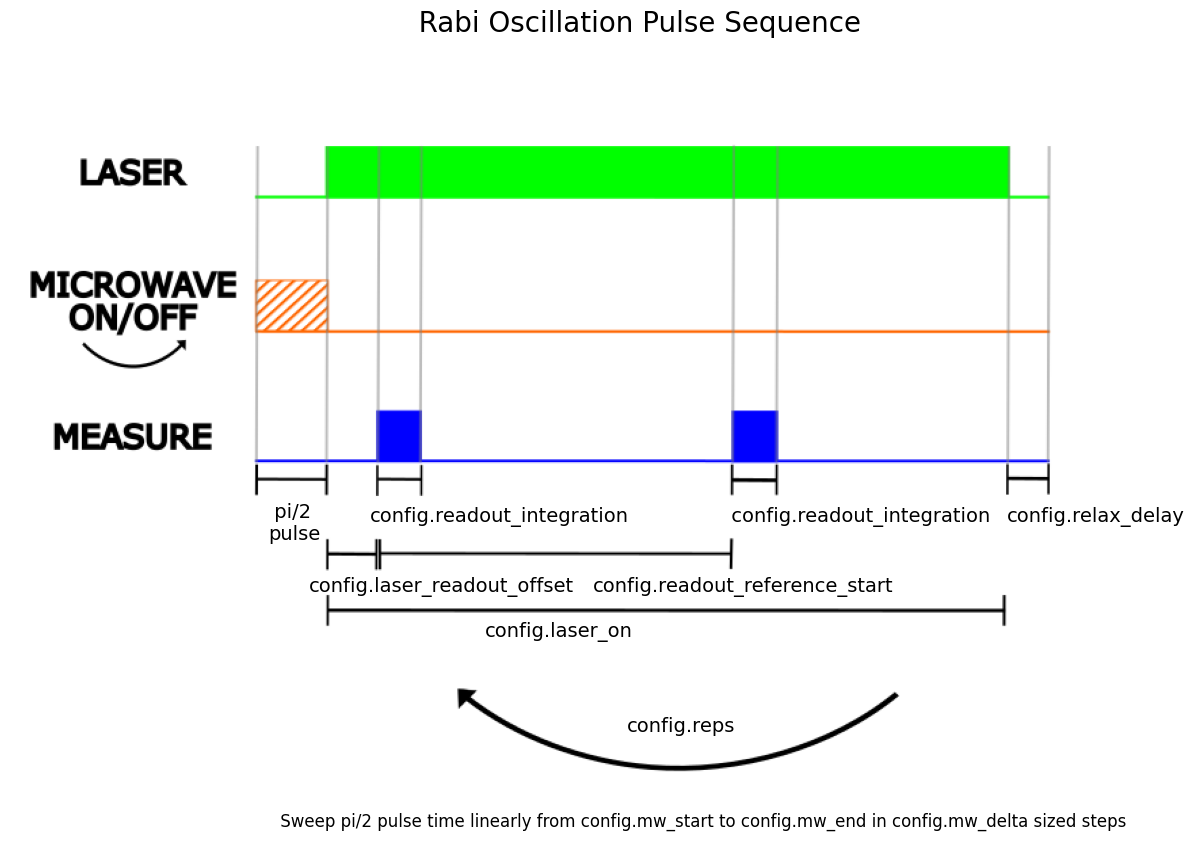

In [2]:
# Show the RabiSweep pulse sequence diagram
qd.RabiSweep.plot_sequence()

In [ ]:
# Rabi oscillation configuration
config_rabi = copy(default_config)

config_rabi.mw_fMHz                  = RESONANCE_FREQ_MHZ
config_rabi.mw_gain                  = 30000        # Maximum gain for fastest Rabi frequency
config_rabi.pre_init                 = True

config_rabi.laser_on_tus             = LASER_ON_TUS
config_rabi.readout_integration_tus  = READOUT_INTEGRATION_TUS
config_rabi.readout_reference_start_tus = READOUT_REF_START_TUS
config_rabi.mw_readout_delay_treg    = MW_READOUT_DELAY_TREG
config_rabi.laser_readout_offset_treg = READOUT_OFFSET_TREG

# Sweep MW pulse length from 4 to 800 register units
# Adjust stop value based on expected Rabi period (start broad, narrow later)
config_rabi.add_linear_sweep('mw', 'treg', start=4, stop=800, delta=4)
config_rabi.reps = 1000

print(f"Sweeping MW pulse length: {config_rabi.mw_start_tns:.0f} to {config_rabi.mw_end_tns:.0f} ns")
print(f"  {config_rabi.nsweep_points} points, {config_rabi.reps} reps")

prog_rabi = qd.RabiSweep(config_rabi)
d_rabi = prog_rabi.acquire(progress=True)

In [ ]:
# Plot raw Rabi oscillations
plt.figure(figsize=(12, 4))
plt.plot(d_rabi.sweep_tus * 1000, d_rabi.contrast_percent, color='steelblue', linewidth=1.5)
plt.xlabel('MW Pulse Duration (ns)')
plt.ylabel('Contrast (%)')
plt.title('Rabi Oscillations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Fit Rabi oscillations to extract π/2 pulse length

def decaying_cosine(t, A, T_rabi, tau_decay, offset):
    """Decaying cosine model for Rabi oscillations.
    t: time in μs
    A: amplitude
    T_rabi: Rabi period in μs
    tau_decay: decay time constant in μs
    offset: baseline offset
    """
    return A * np.cos(2 * np.pi * t / T_rabi) * np.exp(-t / tau_decay) + offset

t_ns = d_rabi.sweep_tus * 1000   # Convert to ns for display
t_us = d_rabi.sweep_tus
x = d_rabi.contrast_percent

# Initial guesses -- adjust if fit fails
A0     = (np.max(x) - np.min(x)) / 2
T0     = 0.4    # Rabi period in μs (initial guess)
tau0   = 1.0    # Decay time in μs
off0   = np.mean(x)

try:
    popt, _ = curve_fit(decaying_cosine, t_us, x, p0=[A0, T0, tau0, off0], maxfev=10000)
    A_fit, T_rabi_us, tau_us, offset_fit = popt

    pi2_pulse_ns  = T_rabi_us / 4 * 1000   # π/2 pulse in ns
    pi_pulse_ns   = T_rabi_us / 2 * 1000   # π pulse in ns

    plt.figure(figsize=(12, 4))
    plt.plot(t_ns, x, color='steelblue', linewidth=1.5, label='Data')
    plt.plot(t_ns, decaying_cosine(t_us, *popt), 'r--', linewidth=2,
             label=f'Fit  T_Rabi={T_rabi_us*1000:.0f} ns  τ={tau_us*1000:.0f} ns')
    plt.axvline(pi2_pulse_ns, color='green', linestyle=':', label=f'π/2 = {pi2_pulse_ns:.0f} ns')
    plt.axvline(pi_pulse_ns,  color='orange', linestyle=':', label=f'π = {pi_pulse_ns:.0f} ns')
    plt.xlabel('MW Pulse Duration (ns)')
    plt.ylabel('Contrast (%)')
    plt.title('Rabi Oscillations with Fit')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Rabi fit results:")
    print(f"  Rabi period:   {T_rabi_us*1000:.0f} ns")
    print(f"  π/2 pulse:     {pi2_pulse_ns:.0f} ns  ← use this in the cell below")
    print(f"  π pulse:       {pi_pulse_ns:.0f} ns")
    print(f"  Decay time:    {tau_us*1000:.0f} ns")

except RuntimeError:
    print("Curve fit failed.")
    print("Try adjusting the initial guesses (A0, T0, tau0) based on the raw plot.")
    print("Alternatively, read the π/2 pulse directly from the first zero crossing.")

In [ ]:
# ===== EDIT THIS: Save calibrated π/2 pulse length =====
PI2_PULSE_NS = 100   # <-- Update from Rabi fit above

print(f"π/2 pulse: {PI2_PULSE_NS} ns")
print(f"π pulse:   {PI2_PULSE_NS * 2} ns")

In [ ]:
# Live Rabi -- useful for fine-tuning MW gain and verifying signal
# Press Stop (■) to exit.

def get_rabi():
    d = prog_rabi.acquire(progress=False)
    return d.sweep_tus * 1000, d.contrast_percent   # (ns, %)

qd.live_plot(get_rabi)

---
## Section 2: Vector Magnetometry Theory

### NV Crystallographic Axes

A diamond crystal has four NV center orientations along the ⟨111⟩ tetrahedral directions (Eq. 1 of *vec_sensing_notes.pdf*):

$$
\hat{n}_1 = \frac{1}{\sqrt{3}}[1,1,1], \quad
\hat{n}_2 = \frac{1}{\sqrt{3}}[1,-1,-1], \quad
\hat{n}_3 = \frac{1}{\sqrt{3}}[-1,1,-1], \quad
\hat{n}_4 = \frac{1}{\sqrt{3}}[-1,-1,1]
$$

Each axis gives **two ESR transitions** (m_s = 0 → +1 and m_s = 0 → −1), producing **8 ODMR peaks** total.

### From Peak Frequencies to Magnetic Field

For a magnetic field **B**, the resonance frequencies for axis *i* are:
$$\nu_i^{\pm} = D \pm \gamma_e |\hat{n}_i \cdot \mathbf{B}|$$

where $D \approx 2.87$ GHz is the zero-field splitting and $\gamma_e = 28$ GHz/T.

The **frequency shift** from a reference state is (Eq. 7):
$$\delta\nu_i = \gamma_e \, \hat{n}_i \cdot \delta\mathbf{B}$$

In matrix form: $\boldsymbol{\delta\nu} = \gamma_e \, A \, \delta\mathbf{B}$, where $A$ is the 4×3 matrix of axis vectors.

### Field Reconstruction (Eq. 8)

The 3D field change is recovered via the pseudo-inverse (Eq. 8):
$$\delta\mathbf{B} = \frac{1}{\gamma_e} T \, \boldsymbol{\delta\nu}, \qquad T = \frac{\sqrt{3}}{4} \begin{pmatrix} 1 & 1 & -1 & -1 \\ 1 & -1 & 1 & -1 \\ 1 & -1 & -1 & 1 \end{pmatrix}$$

This uses **all four axes simultaneously**, giving a vector (not just magnitude) readout with drift cancellation built in.

In [ ]:
# NV axes and transformation matrices (from vec_sensing_notes.pdf)

# Four NV axis unit vectors
nv_axes = np.array([
    [ 1,  1,  1],   # n1
    [ 1, -1, -1],   # n2
    [-1,  1, -1],   # n3
    [-1, -1,  1]    # n4
]) / np.sqrt(3)

GAMMA_E = 28.0    # GHz/T, electron gyromagnetic ratio
D_ZFS   = 2.87    # GHz, zero-field splitting

# Forward matrix A (4x3): delta_nu (GHz) = GAMMA_E * A @ delta_B (T)
A_forward = GAMMA_E * nv_axes

# Inverse matrix T (3x4): delta_B (T) = T @ delta_nu (GHz)
# Eq. 8 of vec_sensing_notes.pdf
s = np.sqrt(3) / 4 / GAMMA_E
T_inverse = s * np.array([
    [ 1,  1, -1, -1],
    [ 1, -1,  1, -1],
    [ 1, -1, -1,  1]
])

# Verify: T @ A should be identity (3x3)
print("Forward matrix A (4x3):  delta_nu = gamma_e * A @ delta_B")
print(np.round(A_forward, 3))

print("\nInverse matrix T (3x4):  delta_B = T @ delta_nu")
print(np.round(T_inverse, 4))

print("\nVerification T @ A (should be identity):")
print(np.round(T_inverse @ A_forward, 4))

---
## Section 3: Wide ODMR — Resolve All 8 NV Peaks

A bias magnetic field (permanent magnet or electromagnet) breaks the degeneracy of the four NV axes, splitting each pair of transitions and making all 8 peaks resolvable.

**Typical range:** 2600–3200 MHz covers ±200 MHz around D = 2870 MHz for a bias field of ~7 mT. Adjust based on your magnet strength.

**Tips:**
- Ensure the bias magnet is stable and in its measurement position.
- If fewer than 8 peaks are visible, increase MW gain or averaging (`reps`).
- Peaks near 2870 MHz (small splitting) indicate axes nearly perpendicular to the bias field.

In [ ]:
# Wide ODMR sweep to find all 8 peaks
config_wide = copy(default_config)

config_wide.readout_integration_tus = qd.max_int_time_tus
config_wide.mw_gain      = 10000    # Moderate gain -- reduce if lines are too broad
config_wide.pre_init     = True
config_wide.reps         = 20       # More averaging for wider sweep
config_wide.relax_delay_treg = 500

# ===== EDIT: adjust sweep range to match your bias field strength =====
config_wide.add_linear_sweep('mw', 'fMHz', start=2600, stop=3200, delta=1)

print(f"Wide ODMR sweep: {config_wide.mw_start_fMHz:.0f} to {config_wide.mw_end_fMHz:.0f} MHz")
print(f"  {config_wide.nsweep_points} points, {config_wide.reps} reps")

prog_wide = qd.LockinODMR(config_wide)
d_wide = prog_wide.acquire(progress=True)

In [ ]:
# Detect and label all 8 peaks

def find_nv_peaks(frequencies, contrast_percent, n_peaks=8, prominence_factor=1.5):
    """Find ODMR dip positions using scipy peak detection.
    Returns (peak_indices, peak_frequencies) sorted by frequency.
    """
    inverted = -contrast_percent
    threshold = np.std(inverted) * prominence_factor
    min_distance = max(1, len(frequencies) // (n_peaks * 3))

    idx, _ = scipy_find_peaks(inverted, height=threshold, distance=min_distance)

    # Sort by frequency
    sort_order = np.argsort(frequencies[idx])
    idx = idx[sort_order]
    return idx, frequencies[idx]


peak_idx, peak_freqs = find_nv_peaks(d_wide.frequencies, d_wide.contrast_percent, n_peaks=8)

plt.figure(figsize=(14, 5))
plt.plot(d_wide.frequencies, d_wide.contrast_percent, color='steelblue', linewidth=1)
plt.plot(d_wide.frequencies[peak_idx], d_wide.contrast_percent[peak_idx],
         'rv', markersize=10, label=f'{len(peak_freqs)} peaks detected')

for i, (idx, freq) in enumerate(zip(peak_idx, peak_freqs)):
    plt.annotate(
        f'{i+1}\n{freq:.1f}',
        xy=(freq, d_wide.contrast_percent[idx]),
        xytext=(0, -22), textcoords='offset points',
        ha='center', fontsize=8, color='darkred'
    )

plt.axvline(D_ZFS * 1000, color='gray', linestyle='--', alpha=0.5, label=f'D = {D_ZFS*1000:.0f} MHz')
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Contrast (%)')
plt.title(f'Wide ODMR Spectrum — {len(peak_freqs)} peaks detected (8 expected)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Detected peaks:")
for i, f in enumerate(peak_freqs):
    print(f"  Peak {i+1}: {f:.2f} MHz")

if len(peak_freqs) < 8:
    print(f"\nWARNING: Only {len(peak_freqs)} peaks found (expected 8).")
    print("Try: increase reps, increase mw_gain, or widen the frequency range.")

---
## Section 4: Peak Assignment to NV Crystallographic Axes

With 8 peaks visible, we pair them by NV axis. Each axis contributes two transitions:
- Lower transition:  $\nu_i^- = D - \gamma_e (\hat{n}_i \cdot \mathbf{B})$
- Upper transition: $\nu_i^+ = D + \gamma_e (\hat{n}_i \cdot \mathbf{B})$

**Pairing strategy (simple, works when peaks are well-resolved):** Match the lowest-frequency peak with the highest, second-lowest with second-highest, etc. The pairs bracket D = 2870 MHz symmetrically.

The axis with the largest splitting corresponds to the crystallographic direction most aligned with the bias field.

In [ ]:
def assign_peaks_to_axes(peak_frequencies, D_MHz=D_ZFS * 1000):
    """
    Pair 8 ODMR peaks into 4 NV axis pairs.

    Strategy: pair outer-to-inner (peak 1 with peak 8, peak 2 with peak 7, etc.).
    This assumes peaks are well-resolved and ordered by frequency.

    Returns
    -------
    pairs : list of 4 tuples (f_lower, f_upper) in MHz, sorted by splitting
    splittings : 1D array of 4 frequency splittings in MHz
    centers : 1D array of 4 pair center frequencies in MHz
    """
    freqs = np.sort(peak_frequencies)
    n = len(freqs)
    n_pairs = n // 2

    pairs      = []
    splittings = []
    centers    = []

    for i in range(n_pairs):
        f_low  = freqs[i]
        f_high = freqs[n - 1 - i]
        pairs.append((f_low, f_high))
        splittings.append(f_high - f_low)
        centers.append((f_low + f_high) / 2)

    # Sort by splitting (smallest → axis most perpendicular to bias field)
    order      = np.argsort(splittings)
    pairs      = [pairs[i] for i in order]
    splittings = np.array([splittings[i] for i in order])
    centers    = np.array([centers[i] for i in order])

    return pairs, splittings, centers


if len(peak_freqs) == 8:
    pairs, splittings, centers = assign_peaks_to_axes(peak_freqs)

    print(f"NV Axis Pairs (sorted by splitting):")
    print(f"{'Axis':>5} | {'f_low (MHz)':>12} | {'f_high (MHz)':>12} | {'Split (MHz)':>12} | {'B_proj (mT)':>11}")
    print("-" * 65)
    for i, ((f_lo, f_hi), split, center) in enumerate(zip(pairs, splittings, centers)):
        B_proj_mT = split / (2 * GAMMA_E * 1e3) * 1e3   # mT
        print(f"  {i+1:>3} | {f_lo:>12.2f} | {f_hi:>12.2f} | {split:>12.2f} | {B_proj_mT:>11.3f}")

    print(f"\nBias field magnitude (from largest splitting): ≈ {splittings[-1]/(2*GAMMA_E*1e3)*1e3:.2f} mT")
else:
    print(f"Need exactly 8 peaks for axis assignment; found {len(peak_freqs)}.")
    print("Re-run the ODMR sweep after adjusting gain or range.")

In [ ]:
# Visualize peak pairs
if len(peak_freqs) == 8:
    colors = ['steelblue', 'darkorange', 'green', 'red']

    plt.figure(figsize=(14, 4))
    plt.plot(d_wide.frequencies, d_wide.contrast_percent, 'k-', linewidth=1, alpha=0.5)

    for i, (f_lo, f_hi) in enumerate(pairs):
        # Shade the region between the pair
        plt.axvspan(f_lo, f_hi, alpha=0.15, color=colors[i], label=f'Axis {i+1}  Δ={splittings[i]:.1f} MHz')
        # Mark the peaks
        for f, marker in [(f_lo, 'v'), (f_hi, 'v')]:
            idx_closest = np.argmin(np.abs(d_wide.frequencies - f))
            plt.plot(f, d_wide.contrast_percent[idx_closest], marker=marker,
                     color=colors[i], markersize=10)

    plt.axvline(D_ZFS * 1000, color='gray', linestyle='--', alpha=0.5, label='D = 2870 MHz')
    plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Contrast (%)')
    plt.title('ODMR Peaks Grouped by NV Axis')
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Section 5: Frequency Shift Tracking & Field Reconstruction

The vector magnetometry measurement workflow:

1. **Reference measurement** — acquire ODMR with known stable field (calibration state)
2. **Current measurement** — acquire ODMR with unknown field
3. **Compute frequency shifts** $\delta\nu_i$ for each axis (center frequency of the pair shifts by the field change projected onto that axis)
4. **Apply transformation** $\delta\mathbf{B} = T \cdot \boldsymbol{\delta\nu} / \gamma_e$ to recover the 3D field change vector

**Note:** This measures *changes* in field (relative to reference). To measure absolute field, calibrate against a known source.

In [ ]:
# Step 1: Reference measurement -- take this with the bias field stable
print("=== Reference Measurement (Calibration) ===")
print("Ensure the bias field is stable and the laser is ON.")

config_ref = copy(default_config)
config_ref.readout_integration_tus = qd.max_int_time_tus
config_ref.mw_gain      = 10000
config_ref.pre_init     = True
config_ref.reps         = 50    # More averaging for reference; reduces frequency uncertainty
config_ref.relax_delay_treg = 500
config_ref.add_linear_sweep('mw', 'fMHz', start=2600, stop=3200, delta=1)

prog_ref = qd.LockinODMR(config_ref)
d_ref = prog_ref.acquire(progress=True)

ref_idx, ref_peak_freqs = find_nv_peaks(d_ref.frequencies, d_ref.contrast_percent, n_peaks=8)
ref_pairs, ref_splittings, ref_centers = assign_peaks_to_axes(ref_peak_freqs)

print(f"\nReference peaks ({len(ref_peak_freqs)} found):")
for i, f in enumerate(ref_peak_freqs):
    print(f"  Peak {i+1}: {f:.2f} MHz")

In [ ]:
# Field measurement function

def measure_field_change(prog, ref_pairs, ref_centers):
    """
    Acquire one ODMR measurement and compute the 3D field change
    relative to the reference measurement.

    Parameters
    ----------
    prog : LockinODMR program (pre-built, reused for speed)
    ref_pairs : list of 4 (f_low, f_high) tuples from reference measurement (MHz)
    ref_centers : array of 4 reference pair center frequencies (MHz)

    Returns
    -------
    dict with field_vector_uT, freq_shifts_MHz, current data
    """
    d = prog.acquire(progress=False)

    cur_idx, cur_peak_freqs = find_nv_peaks(d.frequencies, d.contrast_percent, n_peaks=8)

    if len(cur_peak_freqs) != 8:
        print(f"Warning: found {len(cur_peak_freqs)} peaks, expected 8. Returning None.")
        return None

    cur_pairs, cur_splittings, cur_centers = assign_peaks_to_axes(cur_peak_freqs)

    # Frequency shift per axis = center frequency shift of the pair
    freq_shifts_MHz = cur_centers - ref_centers

    # Convert MHz → GHz, apply transformation matrix
    freq_shifts_GHz = freq_shifts_MHz / 1000
    field_vector_T  = T_inverse @ freq_shifts_GHz   # Tesla

    return {
        'field_vector_T':   field_vector_T,
        'field_vector_uT':  field_vector_T * 1e6,
        'freq_shifts_MHz':  freq_shifts_MHz,
        'current_peaks':    cur_peak_freqs,
        'frequencies':      d.frequencies,
        'contrast_percent': d.contrast_percent
    }

In [ ]:
# Step 2: Single field measurement
print("=== Field Measurement ===")

result = measure_field_change(prog_ref, ref_pairs, ref_centers)

if result is not None:
    print(f"\nFrequency shifts per axis (MHz):")
    for i, shift in enumerate(result['freq_shifts_MHz']):
        print(f"  Axis {i+1}: {shift:+.3f} MHz")

    dB = result['field_vector_uT']
    print(f"\n3D Field change (relative to reference):")
    print(f"  ΔBx = {dB[0]:+.3f} μT")
    print(f"  ΔBy = {dB[1]:+.3f} μT")
    print(f"  ΔBz = {dB[2]:+.3f} μT")
    print(f"  |ΔB| = {np.linalg.norm(dB):.3f} μT")

In [ ]:
# Compare reference vs current ODMR
if result is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax1.plot(d_ref.frequencies, d_ref.contrast_percent,
             'b-', alpha=0.7, linewidth=1.2, label='Reference')
    ax1.plot(result['frequencies'], result['contrast_percent'],
             'r-', alpha=0.7, linewidth=1.2, label='Current')
    ax1.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax1.set_ylabel('Contrast (%)')
    ax1.set_title('ODMR: Reference vs Current')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Interpolate reference onto current frequency grid for subtraction
    ref_interp = np.interp(result['frequencies'], d_ref.frequencies, d_ref.contrast_percent)
    ax2.plot(result['frequencies'], result['contrast_percent'] - ref_interp,
             'g-', linewidth=1.2)
    ax2.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax2.set_ylabel('Difference (Current − Reference)')
    ax2.set_xlabel('Frequency (MHz)')
    ax2.set_title('ODMR Difference (sensitive to field change)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Section 6: Drift Rejection via Field Flipping (Optional)

Slow drifts in the bias field add noise to the measurement. The **field-flipping technique** (Section 5 of *vec_sensing_notes.pdf*) cancels this:

1. Measure with bias field **+B₀**: gives $\boldsymbol{\delta\nu}^+ = \boldsymbol{\nu}_{\text{local}} + \boldsymbol{\nu}_{\text{bias}}$
2. Flip to **−B₀**: gives $\boldsymbol{\delta\nu}^- = \boldsymbol{\nu}_{\text{local}} - \boldsymbol{\nu}_{\text{bias}}$
3. Local field: $\boldsymbol{\delta\nu}_{\text{local}} = (\boldsymbol{\delta\nu}^+ - \boldsymbol{\delta\nu}^-) / 2$

This requires flipping the bias magnet polarity (e.g., reversing current in an electromagnet).

In [ ]:
def measure_with_drift_rejection(prog, ref_pairs, ref_centers):
    """
    Measure the local field with drift rejection by flipping the bias field.
    Requires manual (or automated) control of the bias field polarity.

    Returns
    -------
    local_field_uT : 3-element array, local field in μT
    """
    print("Step 1: Bias field at +B₀")
    input("Press Enter when ready...")
    result_pos = measure_field_change(prog, ref_pairs, ref_centers)
    if result_pos is None:
        return None
    print(f"  +B₀ shifts: {result_pos['freq_shifts_MHz']}")

    print("\nStep 2: Flip bias field to −B₀")
    input("Press Enter when ready...")
    result_neg = measure_field_change(prog, ref_pairs, ref_centers)
    if result_neg is None:
        return None
    print(f"  −B₀ shifts: {result_neg['freq_shifts_MHz']}")

    # Drift-rejected local field
    local_shifts_MHz = (result_pos['freq_shifts_MHz'] - result_neg['freq_shifts_MHz']) / 2
    local_shifts_GHz = local_shifts_MHz / 1000
    local_field_T    = T_inverse @ local_shifts_GHz
    local_field_uT   = local_field_T * 1e6

    print(f"\nDrift-rejected local field:")
    print(f"  ΔBx = {local_field_uT[0]:+.3f} μT")
    print(f"  ΔBy = {local_field_uT[1]:+.3f} μT")
    print(f"  ΔBz = {local_field_uT[2]:+.3f} μT")
    print(f"  |ΔB| = {np.linalg.norm(local_field_uT):.3f} μT")

    return local_field_uT


# Uncomment to run (requires interactive or automated bias field control):
# local_field = measure_with_drift_rejection(prog_ref, ref_pairs, ref_centers)

---
## Section 7: Error Estimation

The field uncertainty propagates from the ODMR frequency measurement uncertainty $\sigma_\nu$.
For homogeneous noise across all 4 axes (Eq. 11 of *vec_sensing_notes.pdf*):

$$\sigma_B = \frac{3}{16 \gamma_e^2} \sum_{i=1}^{4} \sigma_{\nu_i}^2$$

The frequency uncertainty $\sigma_\nu \approx \Delta\nu_{\text{FWHM}} / \text{SNR}$ where $\Delta\nu_{\text{FWHM}}$ is the ODMR linewidth and SNR is the signal-to-noise ratio.

In [ ]:
def estimate_field_uncertainty(freq_uncertainties_MHz):
    """
    Estimate field uncertainty from per-axis frequency uncertainties.
    Based on Eq. 11 of vec_sensing_notes.pdf.

    Parameters
    ----------
    freq_uncertainties_MHz : array of 4 values (one per axis)

    Returns
    -------
    sigma_B_uT : float, field uncertainty in μT
    """
    sigma_nu_GHz = np.asarray(freq_uncertainties_MHz) / 1000
    sigma_B_T = (3 / (16 * GAMMA_E**2)) * np.sum(sigma_nu_GHz**2)
    return sigma_B_T * 1e6   # convert to μT


# ===== EDIT: set your estimated ODMR linewidth and SNR =====
odmr_linewidth_MHz = 5.0    # <-- estimate from your ODMR peaks (FWHM in MHz)
snr                = 10.0   # <-- estimate from contrast / noise floor

freq_unc_MHz = odmr_linewidth_MHz / snr   # per-axis frequency uncertainty
sigma_B_uT   = estimate_field_uncertainty(np.full(4, freq_unc_MHz))

print(f"ODMR linewidth (FWHM):       {odmr_linewidth_MHz:.1f} MHz")
print(f"SNR estimate:                {snr:.1f}")
print(f"Frequency uncertainty:       {freq_unc_MHz:.2f} MHz per axis")
print(f"Field uncertainty:           {sigma_B_uT:.3f} μT per measurement")
print()
print("To improve sensitivity:")
print("  - Increase reps → better SNR → lower σ_ν")
print("  - Reduce ODMR linewidth (lower MW power, better spin coherence)")
print("  - Use Ramsey spectroscopy for narrower linewidth (see qickdawg.Ramsey)")

---
## Section 8: Live Field Monitoring

Continuously acquire ODMR measurements and track the 3D field vector in real time.

In [ ]:
# Live field magnitude monitoring
# Returns |ΔB| in μT for each ODMR acquisition.
# Press Stop (■) to exit.

field_history = []

def get_field_magnitude():
    result = measure_field_change(prog_ref, ref_pairs, ref_centers)
    if result is not None:
        magnitude = np.linalg.norm(result['field_vector_uT'])
        field_history.append(result['field_vector_uT'])
        return magnitude
    return 0.0

# Uncomment to run:
# print("Live |ΔB| monitoring (μT). Press Stop to exit.")
# qd.live_plot(get_field_magnitude)

In [ ]:
# Plot field vector history (after live monitoring)
if len(field_history) > 0:
    history = np.array(field_history)
    t_axis  = np.arange(len(history))

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    labels = ['ΔBx', 'ΔBy', 'ΔBz', '|ΔB|']
    colors = ['steelblue', 'darkorange', 'green', 'red']

    for i in range(3):
        axes[i].plot(t_axis, history[:, i], color=colors[i], linewidth=1.2)
        axes[i].set_ylabel(f'{labels[i]} (μT)')
        axes[i].grid(True, alpha=0.3)
        axes[i].axhline(0, color='k', linewidth=0.5, linestyle='--')

    mag = np.linalg.norm(history, axis=1)
    axes[3].plot(t_axis, mag, color=colors[3], linewidth=1.2)
    axes[3].set_ylabel('|ΔB| (μT)')
    axes[3].set_xlabel('Measurement index')
    axes[3].grid(True, alpha=0.3)

    axes[0].set_title('Field Vector History')
    plt.tight_layout()
    plt.show()
else:
    print("No field history to plot. Run the live monitoring cell first.")

---
## Summary: Complete Measurement Workflow

| Step | Notebook | What you get |
|------|----------|--------------|
| 1. Connect & verify | NB 1, Sec 0 | RFSoC connection, QICK-DAWG working |
| 2. PL readout | NB 1, Sec 2 | ADC signal confirmed on Channel C |
| 3. ODMR spectrum | NB 1, Sec 3 | NV resonance frequency |
| 4. Readout window | NB 1, Sec 4 | `readout_integration_tus`, `laser_on_tus` |
| 5. Rabi oscillations | NB 2, Sec 1 | π/2 pulse length |
| 6. Wide ODMR | NB 2, Sec 3 | All 8 NV peaks resolved |
| 7. Reference measurement | NB 2, Sec 5 | Calibration state |
| 8. Field measurement | NB 2, Sec 5 | 3D field change vector |
| 9. (Optional) Drift rejection | NB 2, Sec 6 | Bias-drift-rejected field |
| 10. Error characterization | NB 2, Sec 7 | Sensitivity estimate |

**For higher sensitivity:** Use Ramsey spectroscopy (`qd.Ramsey`) instead of ODMR for the peak tracking in Section 5. Ramsey has a much narrower linewidth (limited by T₂*) compared to ODMR (limited by MW power broadening), directly improving $\sigma_\nu$ and hence $\sigma_B$.